In [1]:
#descarga de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [2]:
#Cargamos la base de datos
EPH = pd.read_excel("EPH_combinada.xlsx")

In [3]:
# Ya que en el tp anterior no se consideraron las variables, vuelvo a cargar las bases orginales para agregar CH12, CH13, CH14, PP3E_TOT y PP3F_TOT a mi base

# Cargo las bases orginales
eph2005 = pd.read_stata("Individual_t105.dta")
eph2025 = pd.read_excel("usu_individual_T125.xlsx")

In [4]:
eph2005.columns = eph2005.columns.str.upper()

In [5]:
# Filtrar solo región Noroeste
eph2005 = eph2005[eph2005["REGION"]=="NOA"].copy()
eph2025 = eph2025[eph2025["REGION"]== 40].copy()


In [6]:
# --- Análisis de casos con CH12 = 0 en cada año ---

# 1. Filtrar casos con CH12 = 0 en cada base
sin_educacion_2005 = eph2005[eph2005["CH12"] == 0]
sin_educacion_2025 = eph2025[eph2025["CH12"] == 0]

# 2. Ver distribución de edades en esos casos
print("Distribución de edades en CH12 = 0 (2005):")
print(sin_educacion_2005["CH06"].value_counts().sort_index())

print("\nDistribución de edades en CH12 = 0 (2025):")
print(sin_educacion_2025["CH06"].value_counts().sort_index())

# 3. Ver edad mínima y máxima
print("\nEdad mínima y máxima en CH12 = 0 (2005):")
print("Mínima:", sin_educacion_2005["CH06"].min())
print("Máxima:", sin_educacion_2005["CH06"].max())

print("\nEdad mínima y máxima en CH12 = 0 (2025):")
print("Mínima:", sin_educacion_2025["CH06"].min())
print("Máxima:", sin_educacion_2025["CH06"].max())

# 4. Cuántos casos con edad < 1 año
menores1_2005 = sin_educacion_2005[sin_educacion_2005["CH06"] < 1].shape[0]
menores1_2025 = sin_educacion_2025[sin_educacion_2025["CH06"] < 1].shape[0]

print(f"\nCasos con CH12=0 y edad <1 año en 2005: {menores1_2005} de {sin_educacion_2005.shape[0]} totales")
print(f"Casos con CH12=0 y edad <1 año en 2025: {menores1_2025} de {sin_educacion_2025.shape[0]} totales")

Distribución de edades en CH12 = 0 (2005):
CH06
Menos de 1 año    166
1.0               173
2.0               160
3.0               174
4.0               105
                 ... 
94.0                0
95.0                2
96.0                0
97.0                0
98 y más años       0
Name: count, Length: 99, dtype: int64

Distribución de edades en CH12 = 0 (2025):
CH06
-1     51
 1     76
 2     86
 3     50
 4      6
 5      1
 7      1
 8      1
 19     1
 32     1
 34     2
 37     1
 42     1
 46     2
 51     1
 52     1
 53     1
 55     1
 57     1
 61     2
 64     1
 66     1
 68     1
 73     1
 74     2
 78     1
 79     1
 81     1
 82     1
 84     1
 90     1
Name: count, dtype: int64

Edad mínima y máxima en CH12 = 0 (2005):
Mínima: Menos de 1 año
Máxima: 95.0

Edad mínima y máxima en CH12 = 0 (2025):
Mínima: -1
Máxima: 90

Casos con CH12=0 y edad <1 año en 2005: 166 de 885 totales
Casos con CH12=0 y edad <1 año en 2025: 51 de 299 totales


In [10]:
# Filtrar observaciones inválidas en EPH (edad -1)
EPH = EPH[EPH["CH06"] >= 0].copy()

In [11]:
#Me aseguro que el año sea entero
EPH["ANIO"] = EPH["ANIO"].astype("int64")

In [12]:
# ==================================================
# 1. Selección de variables
# ==================================================
vars_educ = [
    "CODUSU", "ANO4", "CH03", "CH12", "CH13", "CH14",
    "PP3E_TOT", "PP3F_TOT"
]

educ2005 = (
    eph2005[vars_educ]
    .rename(columns={"ANO4": "ANIO"})
    .copy()
)

educ2025 = (
    eph2025[vars_educ]
    .rename(columns={"ANO4": "ANIO"})
    .copy()
)

# ==================================================
# 2. Recodificación 2005 (categorías → numérico)
# ==================================================
map_ch12 = {
    "Jardín/Preescolar": 1,
    "Primario": 2,
    "EGB": 3,
    "Secundario": 4,
    "Polimodal": 5,
    "Terciario": 6,
    "Universitario": 7,
    "Posgrado Universitario": 8,
    "Educación especial (discapacitado)": 9,
}

map_ch13 = {
    "Sí": 1,
    "No": 2,
    "Ns./Nr.": 9,
}

educ2005["CH12"] = educ2005["CH12"].map(map_ch12)
educ2005["CH13"] = educ2005["CH13"].map(map_ch13)

# ==================================================
# 3. Limpieza de CH14 (quitar ceros a la izquierda)
# ==================================================
educ2005["CH14"] = (
    educ2005["CH14"]
    .astype(str)
    .str.strip()
    .str.lstrip("0")
    .replace({"": "0"})  # para casos como '00'
)

educ2025["CH14"] = (
    educ2025["CH14"]
    .astype(str)
    .str.strip()
    .str.lstrip("0")
)

# ==================================================
# 4. Ajuste de tipo de dato en ANIO
# ==================================================
educ2005["ANIO"] = educ2005["ANIO"].astype(int)
educ2025["ANIO"] = educ2025["ANIO"].astype(int)

# ==================================================
# 5. Eliminar duplicados por persona y año
# ==================================================
educ2005 = educ2005.groupby(["CODUSU", "ANIO"], as_index=False).first()
educ2025 = educ2025.groupby(["CODUSU", "ANIO"], as_index=False).first()

# ==================================================
# 6. Concatenar 2005 y 2025
# ==================================================
educacion = pd.concat([educ2005, educ2025], ignore_index=True, sort=False)

# ==================================================
# 7. Normalización de CH12, CH13 y CH14
# ==================================================
for col in ["CH12", "CH13", "CH14"]:
    educacion[col] = (
        educacion[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .replace(["nan", "NaN", "", " "], np.nan)
    )

# Convertir a numérico
educacion["CH12"] = pd.to_numeric(educacion["CH12"], errors="coerce")
educacion["CH13"] = pd.to_numeric(educacion["CH13"], errors="coerce")
educacion["CH14"] = pd.to_numeric(educacion["CH14"], errors="coerce")

# Recodificar NS/NC en CH14 (98/99) como NaN
educacion["CH14"] = educacion["CH14"].replace({98: np.nan, 99: np.nan})

# ==================================================
# 7b. Reemplazar 0 por NaN en CH12 y CH13 (casos inválidos o no aplica)
# ==================================================
educacion["CH12"] = educacion["CH12"].replace({0: np.nan})
educacion["CH13"] = educacion["CH13"].replace({0: np.nan})

# ==================================================
# 8. Merge con la base EPH ya combinada
# ==================================================
merge_keys = ["CODUSU", "ANIO"]
EPH_merged = EPH.merge(educacion, on=merge_keys, how="left")

# ==================================================
# 9. Chequeo final de valores
# ==================================================
for col in ["CH12", "CH13", "CH14", "PP3E_TOT", "PP3F_TOT"]:
    print(f"\n{col}:")
    print(EPH_merged[col].value_counts(dropna=False))


CH12:
CH12
4.0    7628
2.0    6476
7.0    2528
6.0    2015
NaN     145
1.0      99
8.0      84
3.0      45
5.0      12
9.0       7
Name: count, dtype: int64

CH13:
CH13
1.0    11512
2.0     7382
NaN      145
Name: count, dtype: int64

CH14:
CH14
NaN    6561
0.0    5840
3.0    2002
2.0    1903
4.0    1109
1.0    1065
5.0     390
6.0     148
7.0      11
8.0      10
Name: count, dtype: int64

PP3E_TOT:
PP3E_TOT
0.0      4305
48.0     1848
40.0     1643
30.0     1413
NaN       993
         ... 
76.0        4
126.0       4
47.0        4
102.0       4
81.0        2
Name: count, Length: 91, dtype: int64

PP3F_TOT:
PP3F_TOT
0.0     16478
NaN       993
20.0      268
10.0      127
15.0      112
24.0      106
12.0      104
8.0        94
4.0        91
18.0       79
6.0        77
16.0       68
25.0       64
30.0       61
9.0        59
3.0        37
5.0        29
2.0        25
28.0       23
21.0       20
14.0       17
7.0        13
35.0       11
40.0       10
26.0        9
11.0        7
27.0       

In [13]:
# Ver si quedan 0 en CH12
print(EPH_merged["CH12"].value_counts(dropna=False))

# Filtrar solo los que sean 0
ch12_0 = EPH_merged[EPH_merged["CH12"] == 0]
print(ch12_0[["CH12","CH06","CH14"]])

CH12
4.0    7628
2.0    6476
7.0    2528
6.0    2015
NaN     145
1.0      99
8.0      84
3.0      45
5.0      12
9.0       7
Name: count, dtype: int64
Empty DataFrame
Columns: [CH12, CH06, CH14]
Index: []


In [14]:
# Imputar CH14 correctamente para quienes completaron el nivel
# Recordar: CH14 solo llega hasta secundaria (máx. 9)

mask = (
    (EPH_merged["CH12"].notna()) 
    & (EPH_merged["CH13"] == 1)     # Finalizó el nivel
    & (EPH_merged["CH14"].isna())   # Falta CH14
    & (EPH_merged["CH12"].isin([4, 5, 6, 7, 8]))  # Secundario, Polimodal, Terciario, Univ, Posgrado
)

# Imputar como secundaria completa (9º aprobado)
EPH_merged.loc[mask, "CH14"] = 9  

print(f"Filas imputadas con CH14=09 (secundaria completa): {mask.sum()}")

Filas imputadas con CH14=09 (secundaria completa): 4335


In [16]:
EPH_merged

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,CAT_OCUP,EMPLEO,PP02B,...,IPCF,CODUSU,NRO_HOGAR,ANIO,CH03,CH12,CH13,CH14,PP3E_TOT,PP3F_TOT
0,1,36,1,4,3,1.0,NaN,3.0,NaN,NaN,...,140.0,125666,1,2005,Jefe,4.0,2.0,2.0,46.0,0.0
1,2,35,1,4,2,3.0,4.0,NaN,NaN,NaN,...,140.0,125666,1,2005,Jefe,4.0,2.0,2.0,46.0,0.0
2,2,15,5,4,3,3.0,3.0,NaN,NaN,NaN,...,140.0,125666,1,2005,Jefe,4.0,2.0,2.0,46.0,0.0
3,1,12,5,4,3,3.0,3.0,NaN,NaN,NaN,...,140.0,125666,1,2005,Jefe,4.0,2.0,2.0,46.0,0.0
4,1,10,5,4,1,3.0,3.0,NaN,NaN,NaN,...,140.0,125666,1,2005,Jefe,4.0,2.0,2.0,46.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19034,2,90,4,1,4,3.0,1.0,0.0,NaN,0.0,...,1250000.0,TQRMNOQYSHMKKRCDEHIBB00882443,1,2025,1,4.0,1.0,9.0,0.0,0.0
19035,2,60,5,1,6,1.0,0.0,3.0,1.0,0.0,...,1250000.0,TQRMNOQYSHMKKRCDEHIBB00882443,1,2025,1,4.0,1.0,9.0,0.0,0.0
19036,2,22,5,1,5,3.0,3.0,0.0,NaN,0.0,...,1250000.0,TQRMNOQYSHMKKRCDEHIBB00882443,1,2025,1,4.0,1.0,9.0,0.0,0.0
19037,1,25,1,4,2,1.0,0.0,3.0,2.0,0.0,...,537500.0,TQRMNOPPVHKOKSCDEHIBB00860370,1,2025,1,2.0,1.0,NaN,36.0,0.0


### Vuelvo a crear la variable "pobre"

In [17]:
# --- 1. Asegurar que CH06 sea numérica ---
EPH_merged["CH06"] = pd.to_numeric(EPH_merged["CH06"], errors="coerce")

# --- 2. Filtrar solo edades válidas (>= 0) ---
EPH_merged = EPH_merged[EPH_merged["CH06"] >= 0].copy()

# --- 3. Crear adulto_equiv según sexo y edad ---
conds = [
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']<1),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==1),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==2),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==3),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==4),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==5),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==6),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==7),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==8),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==9),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==10),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==11),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==12),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==13),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==14),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==15),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==16),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']==17),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06'].between(18,29)),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06'].between(30,45)),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06'].between(46,60)),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06'].between(61,75)),
    (EPH_merged['CH04']==1) & (EPH_merged['CH06']>75),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']<1),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==1),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==2),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==3),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==4),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==5),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==6),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==7),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==8),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==9),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==10),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==11),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==12),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==13),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==14),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==15),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==16),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']==17),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06'].between(18,29)),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06'].between(30,45)),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06'].between(46,60)),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06'].between(61,75)),
    (EPH_merged['CH04']==2) & (EPH_merged['CH06']>75)
]

choices = [0.35, 0.37, 0.46, 0.51, 0.55, 0.60, 0.64, 0.66, 0.68, 0.69,
           0.79, 0.82, 0.85, 0.90, 0.96, 1.00, 1.03, 1.04, 
           1.02, 1.00, 1.00, 0.83, 0.74,  # hombres
           0.35, 0.37, 0.46, 0.51, 0.55, 0.60, 0.64, 0.66, 0.68, 0.69,
           0.70, 0.72, 0.74, 0.76, 0.76, 0.77, 0.77, 0.77,
           0.76, 0.77, 0.76, 0.67, 0.63]  # mujeres

EPH_merged['adulto_equiv'] = np.select(conds, choices, default=np.nan)

# --- 4. Calcular adulto equivalente del hogar ---
EPH_merged['ad_equiv_hogar'] = EPH_merged.groupby(['CODUSU', 'NRO_HOGAR'])['adulto_equiv'].transform('sum')

# --- 5. Calcular ingreso necesario según año ---
cbt_2005 = 205.07
cbt_2025 = 365177

EPH_merged["ingreso_necesario"] = np.where(
    EPH_merged["ANIO"] == 2005,
    EPH_merged["ad_equiv_hogar"] * cbt_2005,
    EPH_merged["ad_equiv_hogar"] * cbt_2025
)

# --- 6. Crear variable pobre (corrigiendo hogares con ingreso ≤ 0) ---
EPH_merged["pobre"] = np.where(
    EPH_merged["ITF"] <= 0,
    1,  # hogares con ingreso ≤ 0 son pobres
    np.where(
        EPH_merged["ITF"] < EPH_merged["ingreso_necesario"],
        1,  # los que no alcanzan el ingreso necesario también son pobres
        0   # el resto son no pobres
    )
)

# --- 7. Comprobación de edades mínimas ---
print("Edad mínima después del filtrado:", EPH_merged["CH06"].min())

# --- 8. Estadísticas descriptivas ---
print(EPH_merged.groupby("pobre")["ITF"].describe())


Edad mínima después del filtrado: 0
        count           mean           std    min     25%     50%        75%  \
pobre                                                                          
0      9926.0  923701.449426  1.219179e+06  150.0  1300.0  4573.0  1681200.0   
1      9113.0  392695.725996  5.642621e+05    0.0   340.0   850.0   745000.0   

              max  
pobre              
0      12300000.0  
1       3828000.0  


# PARTE I


## Ejercicio 1

In [18]:
print("Edad mínima total:", EPH_merged["CH06"].min())
print("Edad mínima pobres:", EPH_merged.loc[EPH_merged["pobre"] == 1, "CH06"].min())
print("Edad mínima no pobres:", EPH_merged.loc[EPH_merged["pobre"] == 0, "CH06"].min())

Edad mínima total: 0
Edad mínima pobres: 0
Edad mínima no pobres: 0


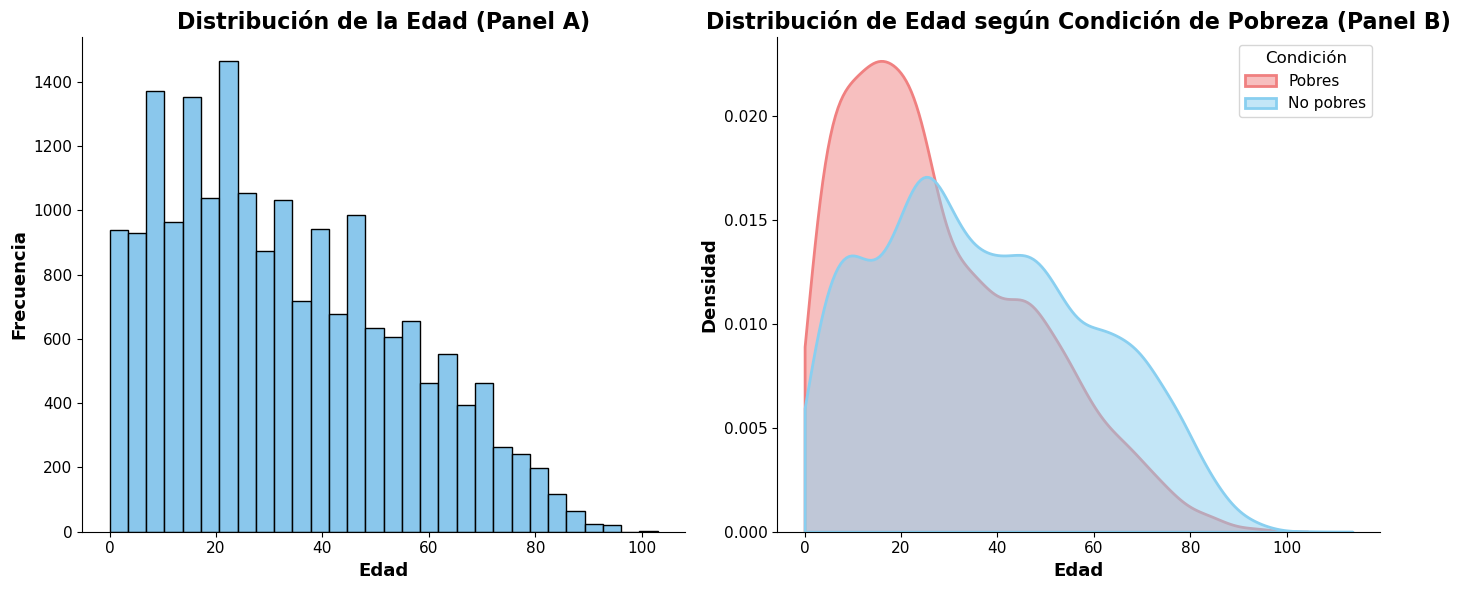

In [19]:
# Crear la variable edad2
EPH_merged["edad2"] = EPH_merged["CH06"] ** 2

# Crear figura con dos paneles
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# === Panel A: Histograma de edad ===
sns.histplot(
    data=EPH_merged,
    x="CH06",
    bins=30,
    color="#76BEE9",           # celeste suave
    edgecolor="black",
    alpha=0.85,
    ax=axes[0]
)
axes[0].set_title("Distribución de la Edad (Panel A)", fontsize=16, weight="bold")
axes[0].set_xlabel("Edad", fontsize=13, weight="bold")
axes[0].set_ylabel("Frecuencia", fontsize=13, weight="bold")
axes[0].tick_params(axis='both', labelsize=11)

# === Panel B: KDE según condición de pobreza ===
sns.kdeplot(
    data=EPH_merged[EPH_merged["pobre"] == 1],
    x="CH06",
    fill=True,
    color="#F08080",           # salmón
    alpha=0.5,
    linewidth=2,
    label="Pobres",
    ax=axes[1],
    clip=(0, None)            
)
sns.kdeplot(
    data=EPH_merged[EPH_merged["pobre"] == 0],
    x="CH06",
    fill=True,
    color="#89CFF0",           # celeste claro
    alpha=0.5,
    linewidth=2,
    label="No pobres",
    ax=axes[1],
    clip=(0, None)
)

axes[1].set_title("Distribución de Edad según Condición de Pobreza (Panel B)", fontsize=16, weight="bold")
axes[1].set_xlabel("Edad", fontsize=13, weight="bold")
axes[1].set_ylabel("Densidad", fontsize=13, weight="bold")
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(title="Condición", title_fontsize=12, fontsize=11, loc="upper right")

# Estilo general
sns.despine()
plt.tight_layout()
plt.show()

## Ejercicio 2

In [20]:
# =========================================
# 1. Función para calcular años de educación
# =========================================
def calcular_educ(row):
    nivel = row["CH12"]
    completo = row["CH13"]
    try:
        ultimo = int(row["CH14"])
    except:
        ultimo = np.nan

    if nivel == 9:  # Educación especial
        return np.nan  

    if nivel == 1:  # Jardín/preescolar
        return 0  

    if nivel == 2:  # Primario
        return 6 if completo == 1 else (ultimo if 1 <= ultimo <= 6 else np.nan)

    if nivel == 3:  # EGB
        return 9 if completo == 1 else (ultimo if 1 <= ultimo <= 9 else np.nan)

    if nivel in [4,5]:  # Secundario/Polimodal
        return 12 if completo == 1 else (6 + ultimo if 1 <= ultimo <= 6 else np.nan)

    if nivel == 6:  # Terciario
        return 15 if completo == 1 else (12 + ultimo if 1 <= ultimo <= 3 else np.nan)

    if nivel == 7:  # Universitario
        return 17 if completo == 1 else (12 + ultimo if 1 <= ultimo <= 5 else np.nan)

    if nivel == 8:  # Posgrado
        return 19 if completo == 1 else (17 + ultimo if 1 <= ultimo <= 2 else np.nan)

    return np.nan

# =========================================
# 2. Aplicar la función sobre EPH_merged
# =========================================
EPH_merged["educ"] = EPH_merged.apply(calcular_educ, axis=1)



In [21]:
# =========================================
# 3. Estadística descriptiva
# =========================================
desc_educ = EPH_merged["educ"].describe(percentiles=[0.5]).to_frame().T
desc_educ = desc_educ.rename(index={"educ": "Años de educación"})
print("Estadística descriptiva de años de educación:")
print(desc_educ[["count","mean","std","min","50%","max"]])

# =========================================
# 4. Resumen de NaN en educ
# =========================================
num_nan = EPH_merged["educ"].isna().sum()
print(f"\nCantidad de casos con educ = NaN: {num_nan}")

# Distribución por rango de edad para interpretar los NaN
bins = [0, 5, 12, 17, 30, 50, 100]
labels = ["0-5","6-12","13-17","18-30","31-50","50+"]
EPH_merged["edad_rango"] = pd.cut(EPH_merged["CH06"], bins=bins, labels=labels)
print("\nDistribución de NaN en educ por rango de edad:")
print(pd.crosstab(EPH_merged["edad_rango"], EPH_merged["educ"].isna()))

Estadística descriptiva de años de educación:
                     count      mean       std  min   50%   max
Años de educación  18168.0  9.795244  4.243369  0.0  10.0  19.0

Cantidad de casos con educ = NaN: 871

Distribución de NaN en educ por rango de edad:
educ        False  True 
edad_rango              
0-5          1300     83
6-12         2230    109
13-17        1577     88
18-30        4187    245
31-50        4608    188
50+          4104    153


## Ejercicio 3

In [22]:
#Un peso en 2005 equivale aproxiamdamente a 969.61 pesos en 2025.
#Multiplicamos ITF por 969.61 si el año es 2005 
EPH_merged["ingreso_total_familiar"] = EPH_merged.apply(
    lambda row: row["ITF"] * 969.61 if row["ANIO"] == 2005 else row["ITF"],
    axis=1
)
print(EPH_merged[["ANIO", "ITF", "ingreso_total_familiar"]].head(10)) #verificamos

   ANIO   ITF  ingreso_total_familiar
0  2005   700               678727.00
1  2005   700               678727.00
2  2005   700               678727.00
3  2005   700               678727.00
4  2005   700               678727.00
5  2005  3800              3684518.00
6  2005  3800              3684518.00
7  2005  3800              3684518.00
8  2005   279               270521.19
9  2005   279               270521.19


### Histograma y Kernels

In [23]:
print(EPH_merged.groupby("pobre")["ingreso_total_familiar"].describe())

        count          mean           std       min       25%        50%  \
pobre                                                                      
0      9926.0  1.776140e+06  1.154979e+06  145441.5  989002.2  1524500.0   
1      9113.0  6.377666e+05  4.934583e+05       0.0  290883.0   581766.0   

             75%         max  
pobre                         
0      2202000.0  12300000.0  
1       890000.0   3828000.0  


In [24]:
#Linea de pobreza

linea_pobreza = 365177

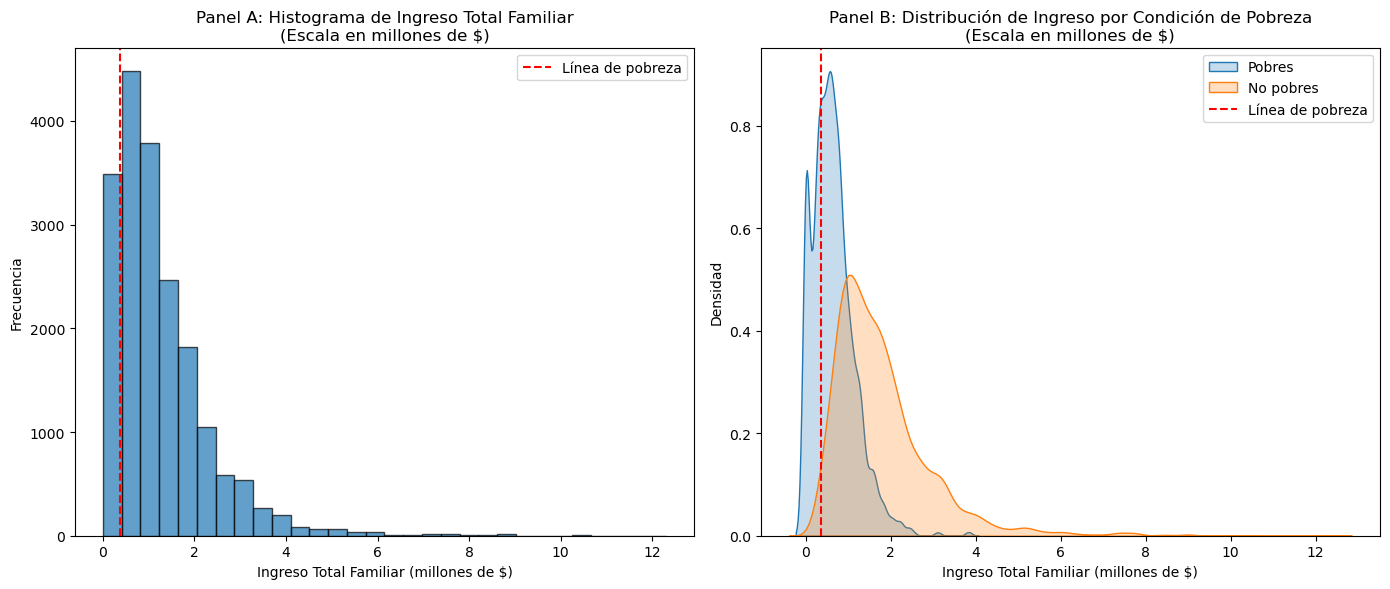

In [25]:
# Crear columna en millones de pesos
EPH_merged["ingreso_total_familiar_millones"] = (
    EPH_merged["ingreso_total_familiar"] / 1_000_000
)

# Línea de pobreza en millones
linea_pobreza_millones = linea_pobreza / 1_000_000

plt.figure(figsize=(14, 6))

# --- Panel A: Histograma general ---
plt.subplot(1, 2, 1)
plt.hist(
    EPH_merged["ingreso_total_familiar_millones"],
    bins=30,
    edgecolor="black",
    alpha=0.7
)
plt.axvline(
    linea_pobreza_millones, color="red", linestyle="--", label="Línea de pobreza"
)
plt.title("Panel A: Histograma de Ingreso Total Familiar\n(Escala en millones de $)", fontsize=12)
plt.xlabel("Ingreso Total Familiar (millones de $)")
plt.ylabel("Frecuencia")
plt.legend()

# --- Panel B: Distribuciones KDE ---
plt.subplot(1, 2, 2)
sns.kdeplot(
    data=EPH_merged[EPH_merged["pobre"] == 1],
    x="ingreso_total_familiar_millones",
    label="Pobres",
    fill=True
)
sns.kdeplot(
    data=EPH_merged[EPH_merged["pobre"] == 0],
    x="ingreso_total_familiar_millones",
    label="No pobres",
    fill=True
)
plt.axvline(
    linea_pobreza_millones, color="red", linestyle="--", label="Línea de pobreza"
)
plt.title("Panel B: Distribución de Ingreso por Condición de Pobreza\n(Escala en millones de $)", fontsize=12)
plt.xlabel("Ingreso Total Familiar (millones de $)")
plt.ylabel("Densidad")
plt.legend()

plt.tight_layout()
plt.show()

## Ejercicio 4

Distribución de CH03 (rol en el hogar):
CH03
Jefe             9331
1                7878
3                1065
2                 331
5                 205
9                  95
4                  77
8                  25
Hijo/Hijastro       9
6                   8
Hermano             8
7                   5
10                  2
Name: count, dtype: int64

Estadísticas descriptivas de horas trabajadas en ocupaciones:
           PP3E_TOT      PP3F_TOT
count  18046.000000  18046.000000
mean      29.303447      1.381082
std       22.573561      5.211367
min        0.000000      0.000000
25%        6.000000      0.000000
50%       30.000000      0.000000
75%       48.000000      0.000000
max      126.000000     63.000000

Observaciones con horas muy altas en la ocupación principal:
       PP3E_TOT  PP3F_TOT
667       120.0       0.0
668       120.0       0.0
669       120.0       0.0
670       120.0       0.0
671       120.0       0.0
...         ...       ...
18504     105.0       0.0
1881

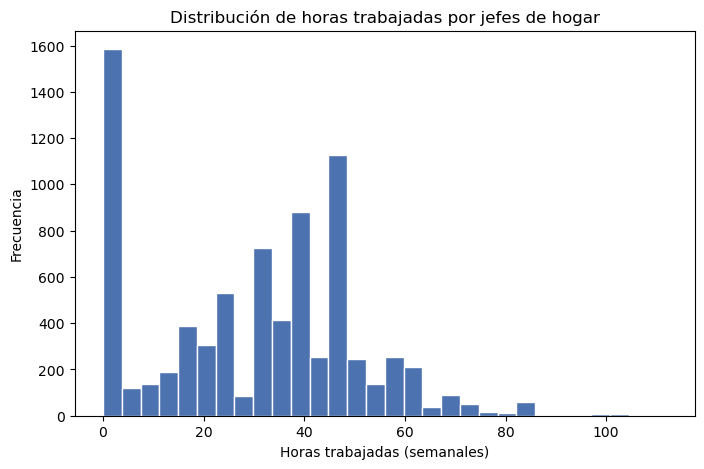

In [26]:
# 1. Crear la variable horastrab
EPH_merged["horastrab"] = EPH_merged["PP3E_TOT"].fillna(0) + EPH_merged["PP3F_TOT"].fillna(0)

# 2. Verificar codificación de CH03 (jefe de hogar)
print("Distribución de CH03 (rol en el hogar):")
print(EPH_merged["CH03"].value_counts(dropna=False))
print()

# 3. Estadísticas básicas de PP3E_TOT y PP3F_TOT
print("Estadísticas descriptivas de horas trabajadas en ocupaciones:")
print(EPH_merged[["PP3E_TOT", "PP3F_TOT"]].describe())
print()

# 4. Buscar valores inusuales (ej: más de 100 horas semanales)
print("Observaciones con horas muy altas en la ocupación principal:")
print(EPH_merged[EPH_merged["PP3E_TOT"] > 100][["PP3E_TOT", "PP3F_TOT"]])
print()

# 5. Filtrar jefes de hogar
jefes = EPH_merged[EPH_merged["CH03"] == 1]

# 6. Chequear cuántos jefes no tienen datos en ninguna de las dos variables
faltantes = jefes[["PP3E_TOT", "PP3F_TOT"]].isna().all(axis=1).sum()
total_jefes = len(jefes)
print(f"Jefes sin datos de horas en ninguna ocupación: {faltantes} de {total_jefes} ({faltantes/total_jefes:.2%})")
print()

# 7. Estadísticas descriptivas de horastrab para jefes
stats = {
    "Promedio": jefes["horastrab"].mean(),
    "Desvío estándar": jefes["horastrab"].std(),
    "Mínimo": jefes["horastrab"].min(),
    "P50 (mediana)": jefes["horastrab"].median(),
    "Máximo": jefes["horastrab"].max()
}
stats_df = pd.DataFrame(stats, index=["horastrab"]).T
print("Estadísticas descriptivas de horas trabajadas por jefes de hogar:")
print(stats_df)

# 8. Histograma de distribución
plt.figure(figsize=(8,5))
jefes["horastrab"].hist(bins=30, color="#4C72B0", edgecolor="white")
plt.xlabel("Horas trabajadas (semanales)")
plt.ylabel("Frecuencia")
plt.title("Distribución de horas trabajadas por jefes de hogar")
plt.grid(False)
plt.show()

In [27]:
#corrijo CH03:

# 1. Normalizar CH03 a string minúscula para detectar etiquetas
EPH_merged["CH03_str"] = EPH_merged["CH03"].astype(str).str.lower().str.strip()

# 2. Crear nueva variable CH03_num mapeando etiquetas a su código oficial
mapa_ch03 = {
    "jefe": 1, "jefe/a": 1, "jefa": 1,
    "cónyuge": 2, "conyuge": 2, "pareja": 2,
    "hijo": 3, "hijo/hijastro": 3, "hijo/hijastro/a": 3, "hijastro": 3, "hijastro/a": 3,
    "yerno": 4, "nuera": 4,
    "nieto": 5, "nieta": 5, "nieto/a": 5,
    "madre": 6, "padre": 6,
    "suegro": 7, "suegra": 7,
    "hermano": 8, "hermana": 8,
    "otros familiares": 9, "otro familiar": 9, "otros": 9,
    "no familiares": 10, "no familiar": 10
}

EPH_merged["CH03"] = EPH_merged["CH03_str"].replace(mapa_ch03)

# 3. Convertir a numérico forzando errores a NaN (por si quedó algo raro)
EPH_merged["CH03"] = pd.to_numeric(EPH_merged["CH03"], errors="coerce")

# 4. Confirmar distribución limpia
print("📊 Nueva distribución limpia de CH03_num:")
print(EPH_merged["CH03"].value_counts(dropna=False))

📊 Nueva distribución limpia de CH03_num:
CH03
1     17209
3      1074
2       331
5       205
9        95
4        77
8        33
6         8
7         5
10        2
Name: count, dtype: int64


In [28]:
# Filtrar jefes con horastrab definidas
jefes = EPH_merged[EPH_merged["CH03"] == 1]

# Detectar outliers > 84h
outliers = jefes[jefes["horastrab"] > 84]
print(f"Casos con más de 84 horas semanales: {len(outliers)} de {len(jefes)} ({len(outliers)/len(jefes):.2%})")

# Mostrar algunos ejemplos
print(outliers[["PP3E_TOT", "PP3F_TOT", "horastrab"]].head(10))

Casos con más de 84 horas semanales: 172 de 17209 (1.00%)
     PP3E_TOT  PP3F_TOT  horastrab
667     120.0       0.0      120.0
668     120.0       0.0      120.0
669     120.0       0.0      120.0
670     120.0       0.0      120.0
671     120.0       0.0      120.0
672     120.0       0.0      120.0
687      90.0       0.0       90.0
688      90.0       0.0       90.0
689      90.0       0.0       90.0
690      90.0       0.0       90.0


In [29]:
faltantes = jefes[["PP3E_TOT", "PP3F_TOT"]].isna().all(axis=1).sum()
print(f"Jefes sin datos en ninguna ocupación: {faltantes} de {len(jefes)} ({faltantes/len(jefes):.2%})")

Jefes sin datos en ninguna ocupación: 919 de 17209 (5.34%)


In [30]:
# Subconjunto final: sin ambas variables NaN y sin outliers
jefes_final = jefes[
    (~jefes[["PP3E_TOT", "PP3F_TOT"]].isna().all(axis=1)) & 
    (jefes["horastrab"] <= 84)
]

# Estadísticas descriptivas finales
stats_final = {
    "Promedio": jefes_final["horastrab"].mean(),
    "Desvío estándar": jefes_final["horastrab"].std(),
    "Mínimo": jefes_final["horastrab"].min(),
    "P50 (mediana)": jefes_final["horastrab"].median(),
    "Máximo": jefes_final["horastrab"].max()
}

stats_final_df = pd.DataFrame(stats_final, index=["horastrab"]).T
print("Estadísticas descriptivas finales (sin faltantes ni outliers):")
print(stats_final_df)

Estadísticas descriptivas finales (sin faltantes ni outliers):
                 horastrab
Promedio         29.406998
Desvío estándar  22.684952
Mínimo            0.000000
P50 (mediana)    30.000000
Máximo           84.000000


## Ejercicio 5

In [31]:
df_region = EPH_merged.copy()

def resumen_base(df):
    return pd.Series({
        "Cantidad observaciones": len(df),
        "Cantidad de observaciones con NAs en pobre": df["pobre"].isna().sum(),
        "Cantidad de pobres": (df["pobre"] == 1).sum(),
        "Cantidad de no pobres": (df["pobre"] == 0).sum(),
        "Cantidad de variables limpias y homogeneizadas": df.shape[1]
    })

# Resumen por año (usa ANIO)
tabla = df_region.groupby("ANIO").apply(resumen_base)

# Agrego fila total
tabla.loc["Total"] = resumen_base(df_region)

print(tabla)

       Cantidad observaciones  Cantidad de observaciones con NAs en pobre  \
ANIO                                                                        
2005                     9348                                           0   
2025                     9691                                           0   
Total                   19039                                           0   

       Cantidad de pobres  Cantidad de no pobres  \
ANIO                                               
2005                 4204                   5144   
2025                 4909                   4782   
Total                9113                   9926   

       Cantidad de variables limpias y homogeneizadas  
ANIO                                                   
2005                                               52  
2025                                               52  
Total                                              52  


C:\Users\rocit\AppData\Local\Temp\ipykernel_53564\2237522884.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla = df_region.groupby("ANIO").apply(resumen_base)


# Parte II: Métodos no Supervisados

Solo necesitamos las variables
- edad
- edad2
- educ 
- ingreso_total_familiar (ITF)
- el número de miembros en el hogar (2005=IX_TOT y 2025=IX_Tot)
- horastrab.

# PCA


## Ejercicio 1

In [32]:
# Contar cuántas observaciones hay por cada valor de educ
conteo_educ = EPH_merged['educ'].value_counts(dropna=False).sort_index()

# Mostrar el conteo
print(conteo_educ)

# Total de observaciones (incluye NAs)
total_obs = EPH_merged['educ'].shape[0]
print(f"\nTotal de observaciones en educ (incluye NAs): {total_obs}")

# Total de observaciones no nulas
total_sin_na = EPH_merged['educ'].notna().sum()
print(f"Total de observaciones no nulas en educ: {total_sin_na}")

# Porcentaje de cada valor
porcentaje_educ = (conteo_educ / total_obs * 100).round(2)
resumen_educ = pd.DataFrame({"Conteo": conteo_educ, "Porcentaje (%)": porcentaje_educ})
print("\nResumen de educ:")
print(resumen_educ)


educ
0.0       99
1.0      215
2.0      435
3.0      415
4.0      386
5.0      261
6.0     4624
7.0      444
8.0      906
9.0     1131
10.0     464
11.0      41
12.0    4456
13.0     394
14.0     565
15.0    1831
16.0     222
17.0    1202
18.0       7
19.0      70
NaN      871
Name: count, dtype: int64

Total de observaciones en educ (incluye NAs): 19039
Total de observaciones no nulas en educ: 18168

Resumen de educ:
      Conteo  Porcentaje (%)
educ                        
0.0       99            0.52
1.0      215            1.13
2.0      435            2.28
3.0      415            2.18
4.0      386            2.03
5.0      261            1.37
6.0     4624           24.29
7.0      444            2.33
8.0      906            4.76
9.0     1131            5.94
10.0     464            2.44
11.0      41            0.22
12.0    4456           23.40
13.0     394            2.07
14.0     565            2.97
15.0    1831            9.62
16.0     222            1.17
17.0    1202            6.3

In [33]:
## Agrego IX_TOT de ambos años ya que se encuentran en la base de hogares y veníamos trabajando con la individual
#Cargo bases de hogares

hogar2005 = pd.read_stata("Hogar_t105.dta") 
hogar2025 = pd.read_excel("usu_hogar_T125.xlsx")

In [34]:

# Pasar a mayúsculas por consistencia
hogar2005.columns = hogar2005.columns.str.upper()
hogar2025.columns = hogar2025.columns.str.upper()

# =============================
# 2. FILTRAR SOLO NOA
# =============================

hogar2005 = hogar2005[hogar2005["REGION"]=="NOA"].copy()
hogar2025 = hogar2025[hogar2025["REGION"]==40].copy()

# =============================
# 3. VARIABLES NECESARIAS
# =============================

vars_hogar = ["CODUSU", "NRO_HOGAR", "IX_TOT", "ANO4"]

hogar2005 = hogar2005[vars_hogar].rename(columns={"ANO4":"ANIO"})
hogar2025 = hogar2025[vars_hogar].rename(columns={"ANO4":"ANIO"})

# Asegurar tipo int para merge
hogar2005["ANIO"] = hogar2005["ANIO"].astype(int)
hogar2025["ANIO"] = hogar2025["ANIO"].astype(int)

# =============================
# 4. UNIR HOGARES DE AMBOS AÑOS
# =============================

hogares = pd.concat([hogar2005, hogar2025], ignore_index=True, sort=False)

# =============================
# 5. MERGE CON TU BASE COMBINADA EPH
# =============================

merge_keys = ["CODUSU", "NRO_HOGAR", "ANIO"]

EPH_merged = EPH_merged.merge(hogares, on=merge_keys, how="left")

# =============================
# 6. CHEQUEO
# =============================

print(EPH_merged[["ANIO", "IX_TOT"]].head())
print("Individuos antes:", len(EPH_merged))
print("Individuos después:", len(EPH_merged))


   ANIO  IX_TOT
0  2005     5.0
1  2005     5.0
2  2005     5.0
3  2005     5.0
4  2005     5.0
Individuos antes: 19039
Individuos después: 19039


Matriz de correlaciones:

                        CH06  edad2  educ  ingreso_total_familiar  IX_TOT  \
CH06                    1.00   0.96  0.03                    0.06   -0.32   
edad2                   0.96   1.00  0.00                    0.05   -0.30   
educ                    0.03   0.00  1.00                    0.25   -0.29   
ingreso_total_familiar  0.06   0.05  0.25                    1.00    0.12   
IX_TOT                 -0.32  -0.30 -0.29                    0.12    1.00   
horastrab              -0.17  -0.19  0.11                    0.10    0.06   

                        horastrab  
CH06                        -0.17  
edad2                       -0.19  
educ                         0.11  
ingreso_total_familiar       0.10  
IX_TOT                       0.06  
horastrab                    1.00  


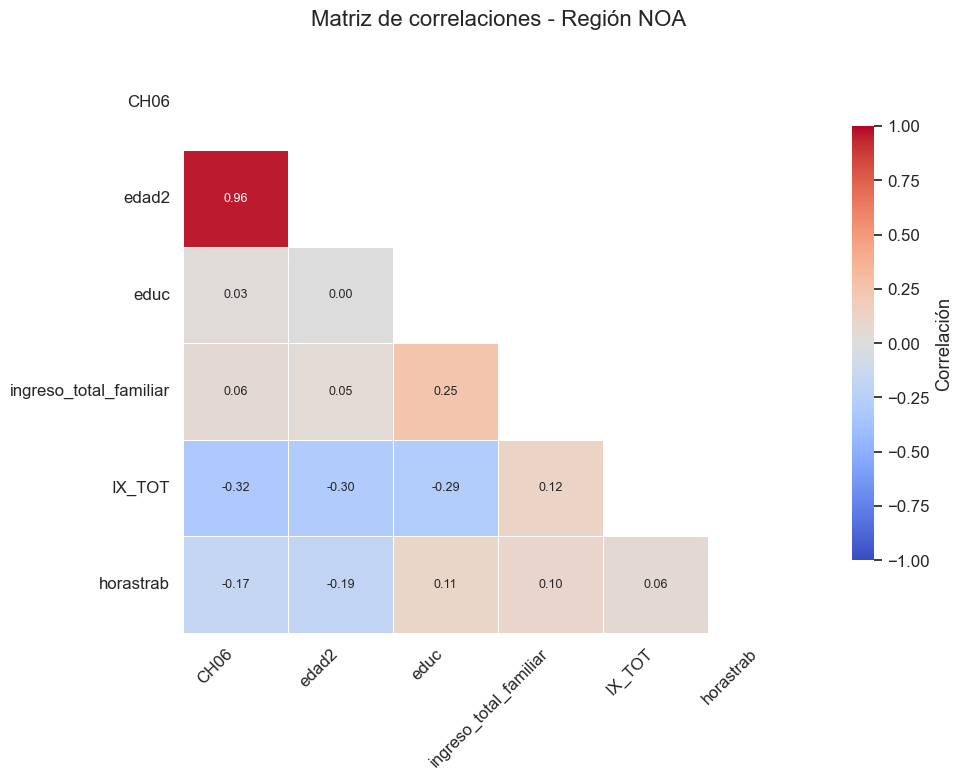

In [35]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Variables a usar
vars_corr = ["CH06", "edad2", "educ", "ingreso_total_familiar", "IX_TOT", "horastrab"]

# Subset de la base, eliminando filas con NaN en estas variables
df_corr = EPH_merged[vars_corr].dropna()

# Calcular matriz de correlaciones de Pearson
corr_matrix = df_corr.corr()

print("Matriz de correlaciones:\n")
print(corr_matrix.round(2))

# Crear máscara para ocultar mitad superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Estilo de seaborn
sns.set_style("white")
sns.set_context("notebook", font_scale=1.1)

# Graficar heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.75, "label": "Correlación"},
    annot_kws={"size": 9}
)

# Rotación de etiquetas
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# Título
plt.title("Matriz de correlaciones - Región NOA", fontsize=16, pad=20)

plt.tight_layout()
plt.show()

## Ejercicio 2

In [36]:
#Primero instalá factor_analyzer si no lo tenés
!pip install factor_analyzer

from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

In [37]:
# Variables seleccionadas
vars_corr = ["CH06", "edad2", "educ", "ingreso_total_familiar", "IX_TOT", "horastrab"]

# Subset sin valores faltantes
df_corr = EPH_merged[vars_corr].dropna()

# KMO
kmo_all, kmo_model = calculate_kmo(df_corr)
print(" KMO por variable:")
for var, kmo_val in zip(vars_corr, kmo_all):
    print(f"{var}: {kmo_val:.3f}")
print(" KMO general:", round(kmo_model,3))

# Interpretación rápida:
# >0.80: excelente, 0.70-0.79: aceptable, 0.60-0.69: mediocre, <0.60: no recomendable

# 2️Test de esfericidad de Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(df_corr)
print("\n Test de Bartlett")
print(f"Chi²: {chi_square_value:.2f}, p-value: {p_value:.4f}")

# Interpretación:
# p < 0.05 → la matriz de correlaciones no es identidad → PCA apropiado


 KMO por variable:
CH06: 0.532
edad2: 0.531
educ: 0.416
ingreso_total_familiar: 0.375
IX_TOT: 0.607
horastrab: 0.773
 KMO general: 0.528

 Test de Bartlett
Chi²: 52943.42, p-value: 0.0000


In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Variables seleccionadas
vars_corr = ["CH06", "edad2", "educ", "ingreso_total_familiar", "IX_TOT", "horastrab"]

# Subset sin valores faltantes
df_corr = EPH_merged[vars_corr].dropna()

# Estandarización
scaler = StandardScaler(with_mean=True, with_std=True)
df_std = pd.DataFrame(scaler.fit_transform(df_corr), columns=vars_corr)

print("Media tras estandarización:\n", df_std.mean())
print("Desvío estándar tras estandarización:\n", df_std.std())

Media tras estandarización:
 CH06                      7.196162e-17
edad2                    -5.475340e-17
educ                     -9.073421e-17
ingreso_total_familiar    9.386298e-18
IX_TOT                    6.257532e-18
horastrab                 2.815889e-17
dtype: float64
Desvío estándar tras estandarización:
 CH06                      1.000028
edad2                     1.000028
educ                      1.000028
ingreso_total_familiar    1.000028
IX_TOT                    1.000028
horastrab                 1.000028
dtype: float64


In [39]:
# PCA
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(df_std)

# Convertimos a DataFrame
pca_df = pd.DataFrame(pca_scores, columns=['PC1', 'PC2'])

# Varianza explicada por cada componente
print(" Varianza explicada por cada componente:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Componente {i+1}: {var:.2%}")

# Varianza total explicada por los dos primeros
print("\nVarianza total explicada:", pca.explained_variance_ratio_.sum().round(2))

 Varianza explicada por cada componente:
Componente 1: 36.54%
Componente 2: 22.33%

Varianza total explicada: 0.59


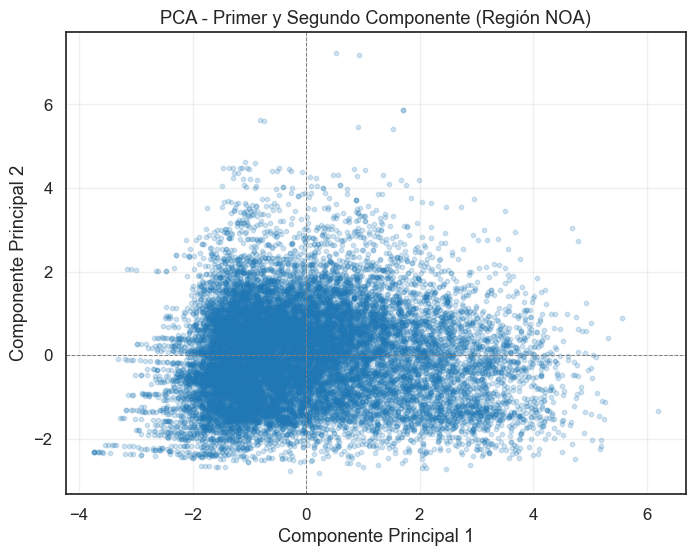

In [40]:
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.2, s=10)  # alpha bajo y puntos chicos
plt.title('PCA - Primer y Segundo Componente (Región NOA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.7)
plt.grid(alpha=0.3)
plt.show()

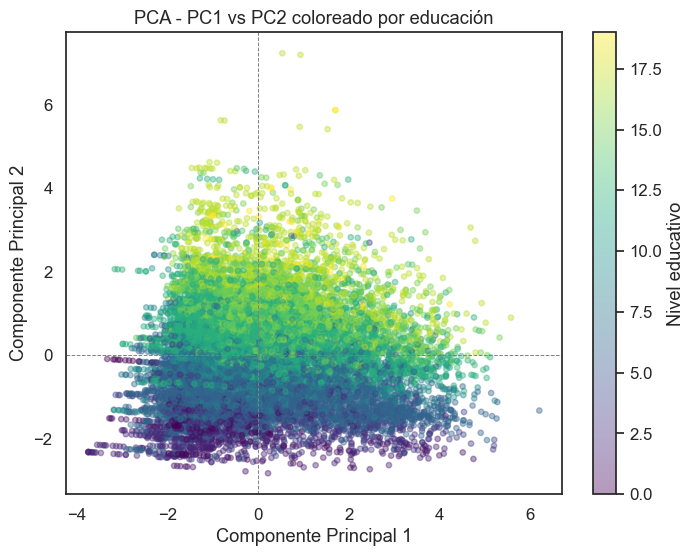

In [41]:
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=df_corr['educ'], cmap='viridis', alpha=0.4, s=15)
plt.colorbar(label='Nivel educativo')
plt.title('PCA - PC1 vs PC2 coloreado por educación')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.7)
plt.show()

## Ejercicio 3

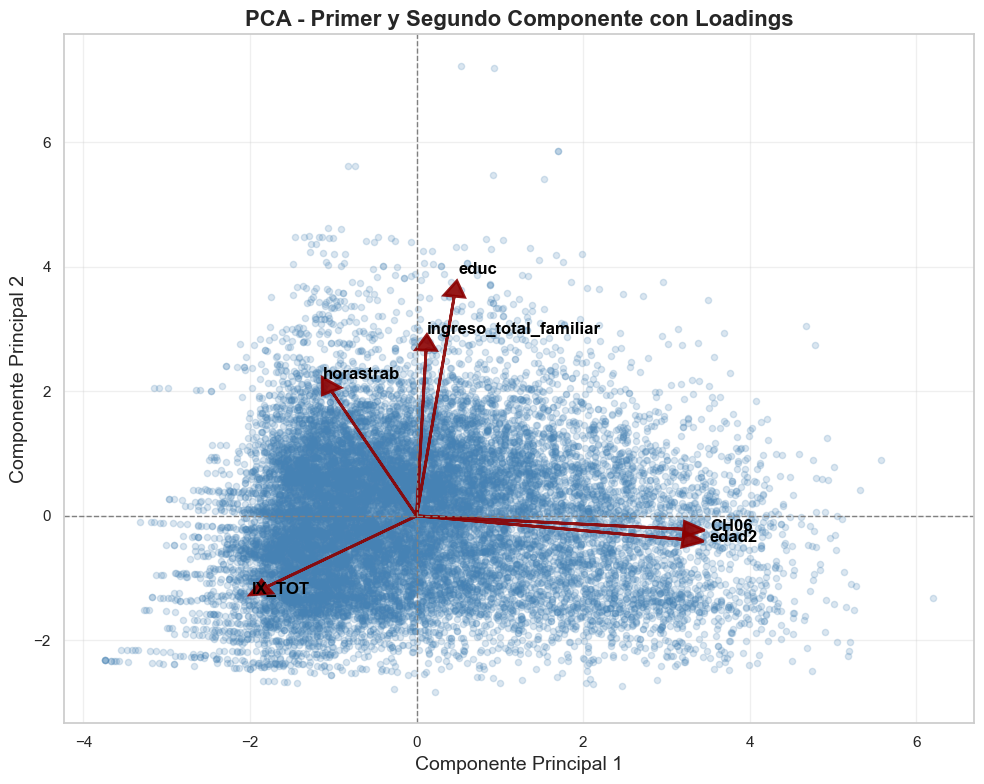

In [42]:
sns.set(style="whitegrid")  # estilo limpio

loadings = pca.components_.T  # columnas = componentes
variables = df_std.columns

plt.figure(figsize=(10,8))

# Nube de puntos de individuos
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.2, s=20, color='steelblue', label='Individuos')

# Flechas de loadings
for i, var in enumerate(variables):
    plt.arrow(0, 0, loadings[i,0]*5, loadings[i,1]*5, 
              color='darkred', alpha=0.9, head_width=0.25, head_length=0.25, linewidth=2)
    plt.text(loadings[i,0]*5.5, loadings[i,1]*5.5, var, color='black', fontsize=12, weight='bold')

# Líneas centrales
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# Etiquetas y título
plt.title('PCA - Primer y Segundo Componente con Loadings', fontsize=16, weight='bold')
plt.xlabel('Componente Principal 1', fontsize=14)
plt.ylabel('Componente Principal 2', fontsize=14)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Ejercicio 4

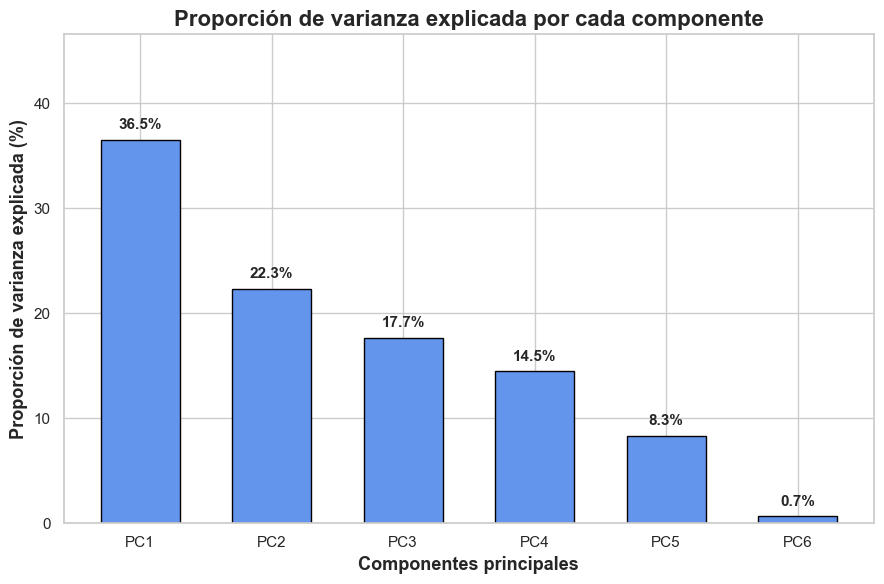

In [43]:
# Asegurarnos de tener PCA con todas las variables
pca_full = PCA(n_components=6)
pca_full.fit(df_std)
explained_var = pca_full.explained_variance_ratio_

# Configuración estética
sns.set(style="whitegrid")
plt.figure(figsize=(9,6))

components = [f'PC{i+1}' for i in range(len(explained_var))]
bars = plt.bar(components, explained_var*100, color='cornflowerblue', edgecolor='black', width=0.6)

# Etiquetas de ejes y título
plt.ylabel('Proporción de varianza explicada (%)', fontsize=13, weight='bold')
plt.xlabel('Componentes principales', fontsize=13, weight='bold')
plt.title('Proporción de varianza explicada por cada componente', fontsize=16, weight='bold')
plt.ylim(0, max(explained_var*100)+10)

# Mostrar los valores sobre cada barra
for bar, v in zip(bars, explained_var*100):
    plt.text(bar.get_x() + bar.get_width()/2, v + 1, f"{v:.1f}%", ha='center', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

# Cluster

## Ejercicio 5 

### Parte A

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set(style="whitegrid")

# ------------------------------
# Seleccionar variables necesarias
df_cluster = EPH_merged[['edad2', 'ingreso_total_familiar', 'pobre']].copy()

# Recorte de outliers (1% - 99%)
low, high = df_cluster['ingreso_total_familiar'].quantile([0.01, 0.99])
df_cluster = df_cluster[
    (df_cluster['ingreso_total_familiar'] >= low) &
    (df_cluster['ingreso_total_familiar'] <= high)
]

# ------------------------------
# Normalización
X = df_cluster[['edad2', 'ingreso_total_familiar']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [46]:
# ------------------------------
# Función para correr K-means y graficar
def kmeans_cluster_compare(X_scaled, df_orig, k, n_init=20):
    kmeans = KMeans(n_clusters=k, n_init=n_init, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    
    df_plot = df_orig.copy()
    df_plot['cluster'] = clusters
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
    
    # --- Panel 1: Resultado de K-means ---
    sns.scatterplot(
        data=df_plot, x='edad2', y='ingreso_total_familiar',
        hue='cluster', palette='Set2', alpha=0.6, s=35, ax=axes[0]
    )
    centroids = scaler.inverse_transform(kmeans.cluster_centers_)
    axes[0].scatter(
        centroids[:, 0], centroids[:, 1],
        c='white', edgecolors='red', linewidth=2,
        s=200, marker='X', label='Centroides'
    )
    axes[0].set_title(f"K-Means (k={k})")
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # --- Panel 2: Pobre vs no pobre ---
    sns.scatterplot(
        data=df_plot, x='edad2', y='ingreso_total_familiar',
        hue='pobre', palette={0: 'blue', 1: 'red'}, alpha=0.6, s=35, ax=axes[1]
    )
    axes[1].set_title("Etiqueta real: pobre vs no pobre")
    axes[1].legend(title="Pobre", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # --- Ejes ---
    for ax in axes:
        ax.set_xlabel("Edad^2")
        ax.set_ylabel("Ingreso familiar (pesos 2025)")
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return clusters

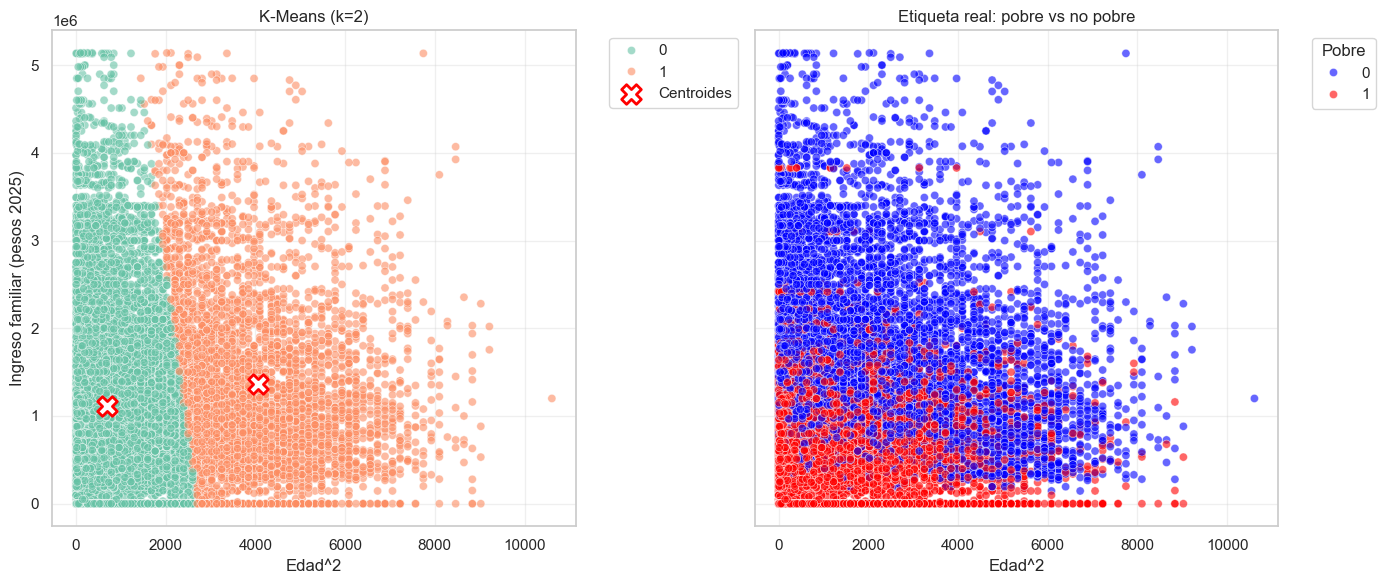

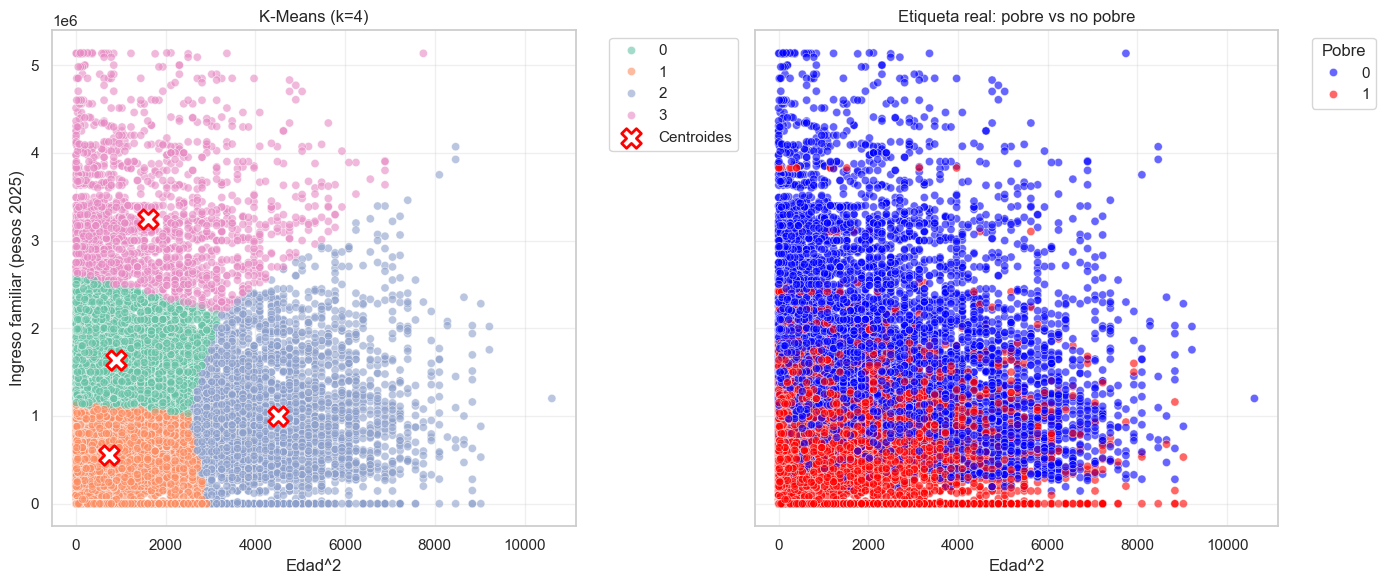

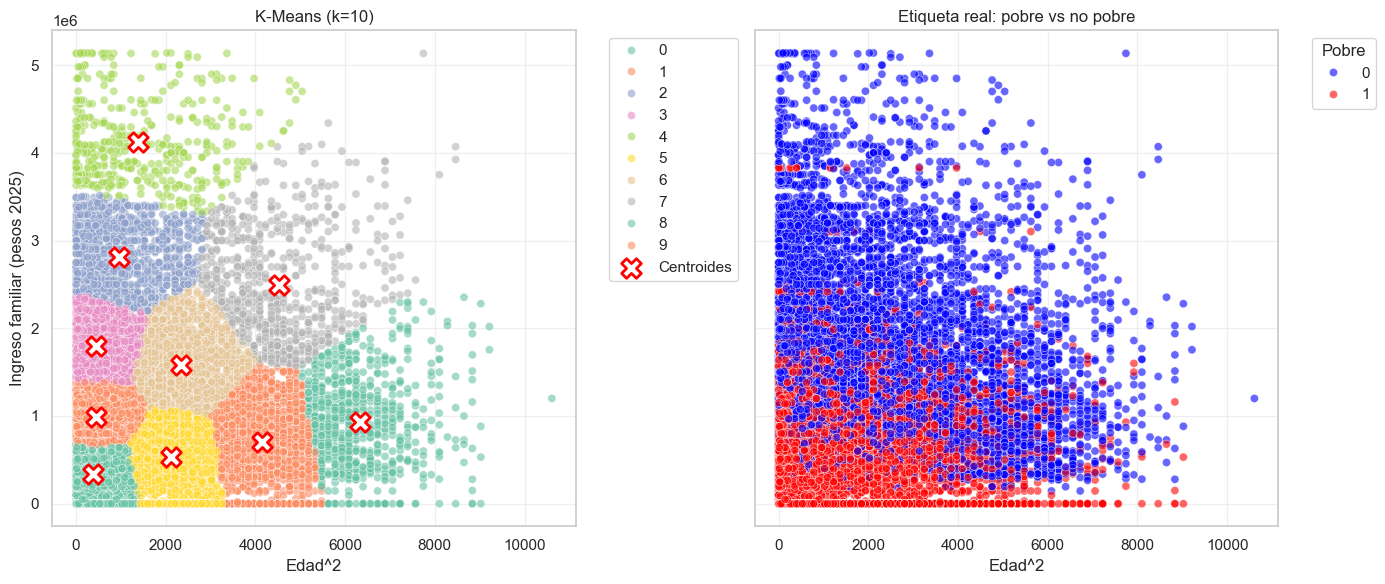

In [47]:
# ------------------------------
# Correr K-means con k = 2, 4 y 10
clusters_2 = kmeans_cluster_compare(X_scaled, df_cluster, k=2, n_init=20)
clusters_4 = kmeans_cluster_compare(X_scaled, df_cluster, k=4, n_init=20)
clusters_10 = kmeans_cluster_compare(X_scaled, df_cluster, k=10, n_init=20)

## Parte B


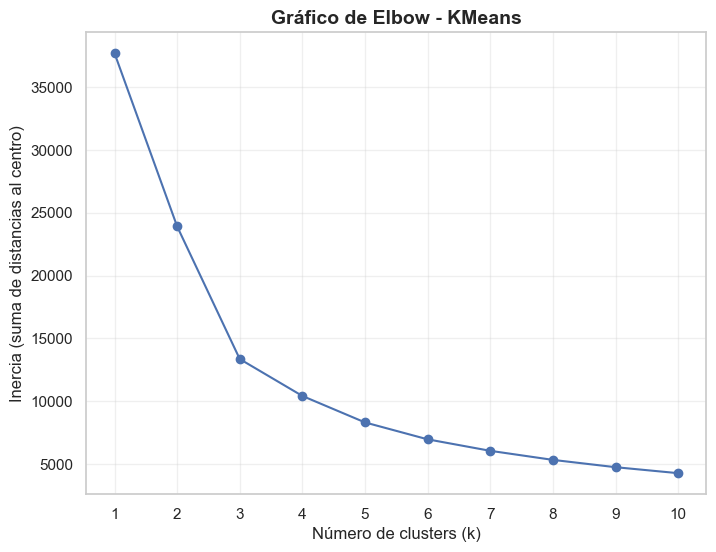

In [48]:
# ------------------------------
# Elbow method: inercia para k=1..10
# ------------------------------
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    kmeans.fit(X_scaled)  
    inertias.append(kmeans.inertia_)

# ------------------------------
# Gráfico del codo
# ------------------------------
plt.figure(figsize=(8,6))
plt.plot(K_range, inertias, marker='o')
plt.title("Gráfico de Elbow - KMeans", fontsize=14, weight='bold')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (suma de distancias al centro)")
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.show()

## Ejercicio 6

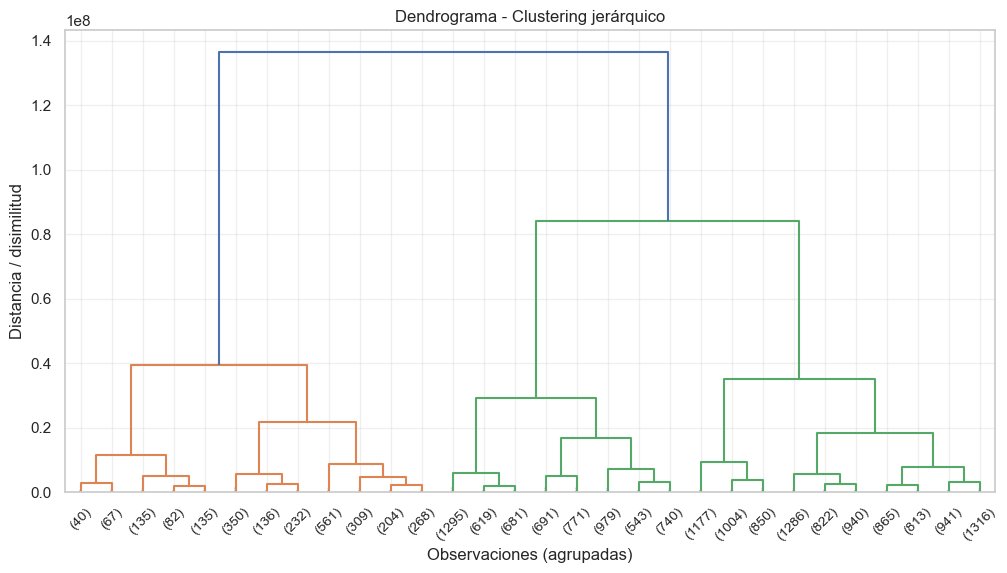

In [49]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# ------------------------------
# Preparamos datos (ya estandarizados con X)
# ------------------------------
# X es el array escalado con CH06 e ingreso
# Si no lo tenés cargado, recordá hacer:
# scaler = StandardScaler()
# X = scaler.fit_transform(df_cluster[['CH06','ingreso_total_familiar_millones']])

# ------------------------------
# Clustering jerárquico
# ------------------------------
Z = linkage(X, method='ward')  
# 'ward' minimiza la varianza intra-cluster
# otras opciones: 'complete', 'average', 'single'

# ------------------------------
# Dendrograma
# ------------------------------
plt.figure(figsize=(12,6))
dendrogram(
    Z,
    truncate_mode="lastp",  # mostrar solo últimos clusters si hay muchos datos
    p=30,                   # cuántos clusters mostrar (ajustar según tamaño de muestra)
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True
)
plt.title("Dendrograma - Clustering jerárquico")
plt.xlabel("Observaciones (agrupadas)")
plt.ylabel("Distancia / disimilitud")
plt.grid(alpha=0.3)
plt.show()